In [206]:
import pandas as pd 
import numpy as np 
from datetime import timedelta
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

In [207]:
# ------------------------------
# HYPERPARAMETERS & SETTINGS
# ------------------------------

# Model & Training Config
FEATURES = ['observations', 'dayofweek', 'is_weekend', 'day', 'month', 'moving_avg', 'ema']
HIDDEN_LAYERS = [32,16]  # Increase model complexity with more layers
ACTIVATION = nn.ReLU
DROPOUT = 0.4  # Increase dropout rate to reduce overfitting
LOSS_FN = nn.BCEWithLogitsLoss
OPTIMIZER_FN = optim.Adam
LEARNING_RATE = 0.0005  # Reduce learning rate for more stable training
WEIGHT_DECAY = 0.0001  # Increase weight decay for regularization
EPOCHS = 100  # Reduce epochs to prevent overfitting
BATCH_SIZE = 128  # Increase batch size for faster training
SEED = 42
TEST_SIZE = 0.3
N_SAMPLES = 1000  # Simulate data for 30 days
BEST_LOSS = float('inf')  # Start with a very high loss
PATIENCE = 100  # Reduce patience to stop earlier if no improvement
PATIENCE_COUNTER = 0 # Counter for early stopping
LAG_DAYS = 7


In [208]:
#import data from /Users/jaytlinaskew/GitRepository/TimeSeries-Analysis/data/processed/ProcessedObservedData.csv
data = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\FullIndicatorMatrix.csv')

data.head(10)

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen
0,818860012482918321,2025-01-01,146.71.50.198,1,2,False,1,1,1
1,818860012482918321,2025-01-01,149.36.49.225,28,2,False,1,1,1
2,818860012482918321,2025-01-01,162.142.125.242,3,2,False,1,1,1
3,818860012482918321,2025-01-01,162.142.125.247,2,2,False,1,1,1
4,818860012482918321,2025-01-01,162.142.125.255,3,2,False,1,1,1
5,818860012482918321,2025-01-01,185.230.63.171,6,2,False,1,1,1
6,818860012482918321,2025-01-01,23.26.221.12,49,2,False,1,1,1
7,818860012482918321,2025-01-01,23.26.221.2,51,2,False,1,1,1
8,818860012482918321,2025-01-01,23.26.221.4,36,2,False,1,1,1
9,818860012482918321,2025-01-01,34.160.111.145,4,2,False,1,1,1


In [209]:
# Ensure all feature columns are numeric
data['observations'] = pd.to_numeric(data['observations'], errors='coerce')
data['dayofweek'] = pd.to_numeric(data['dayofweek'], errors='coerce')
data['is_weekend'] = pd.to_numeric(data['is_weekend'], errors='coerce')
data['day'] = pd.to_numeric(data['day'], errors='coerce')
data['month'] = pd.to_numeric(data['month'], errors='coerce')
# Add moving average feature
window_size = 7  # Example: 7-day moving average
data['moving_avg'] = data['observations'].rolling(window=window_size, min_periods=1).mean()
# Add exponential moving average feature
alpha = 0.3  # Smoothing factor
data['ema'] = data['observations'].ewm(alpha=alpha, adjust=False).mean()
# Ensure all feature columns are numeric
data['moving_avg'] = pd.to_numeric(data['moving_avg'], errors='coerce')
data['ema'] = pd.to_numeric(data['ema'], errors='coerce')

# Drop rows with missing values
data = data.dropna()

In [210]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# ---------------------------
# Prepare sequence + labels
# ---------------------------
sequence_length = 30
predict_window = 7

# Prepare sequences with all features
X, y = [], []

for indicator in data['indicator'].unique():
    indicator_data = data[data['indicator'] == indicator]
    for i in range(len(indicator_data) - sequence_length - predict_window):
        # Extract sequence of features (including moving_avg and ema)
        seq = indicator_data[FEATURES].iloc[i:i + sequence_length].values
        # Determine label based on future 'seen' values
        future = indicator_data['seen'].iloc[i + sequence_length:i + sequence_length + predict_window].values
        label = 1 if future.sum() > 0 else 0
        X.append(seq)
        y.append(label)

# Convert to NumPy arrays
X = np.array(X)  # Shape: (num_samples, sequence_length, num_features)
y = np.array(y).reshape(-1, 1)  # Shape: (num_samples, 1)

# Split and convert to tensors
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Ensure all elements in X_train, X_test, y_train, and y_test are numeric
X_train = torch.tensor(X_train.astype(np.float32), dtype=torch.float32)
y_train = torch.tensor(y_train.astype(np.float32), dtype=torch.float32)
X_test = torch.tensor(X_test.astype(np.float32), dtype=torch.float32)
y_test = torch.tensor(y_test.astype(np.float32), dtype=torch.float32)

# Create DataLoaders
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64)

# Confirm shapes (optional)
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: torch.Size([10874, 30, 7]) torch.Size([10874, 1])
Test: torch.Size([2719, 30, 7]) torch.Size([2719, 1])


In [211]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)  # Output layer for binary classification

    def forward(self, x):
        out, _ = self.lstm(x)  # LSTM output
        out = self.dropout(out[:, -1, :])  # Take the output of the last time step
        return self.fc(out)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMModel(input_size=len(FEATURES), hidden_size=HIDDEN_LAYERS[0], num_layers=len(HIDDEN_LAYERS), dropout=DROPOUT).to(device)

In [212]:
# ----------------------------
# Loss & Optimizer
# ----------------------------
loss_fn = LOSS_FN() # create the loss function using the loss function specified in the hyperparameters
optimizer = OPTIMIZER_FN(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY) # create the optimizer using the optimizer specified in the hyperparameters

Epoch 10 | Train Loss: 0.5069 | Test Loss: 0.5203
Epoch 20 | Train Loss: 0.4599 | Test Loss: 0.4879
Epoch 30 | Train Loss: 0.4283 | Test Loss: 0.4652
Epoch 40 | Train Loss: 0.3932 | Test Loss: 0.4339
Epoch 50 | Train Loss: 0.3646 | Test Loss: 0.4254


C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.



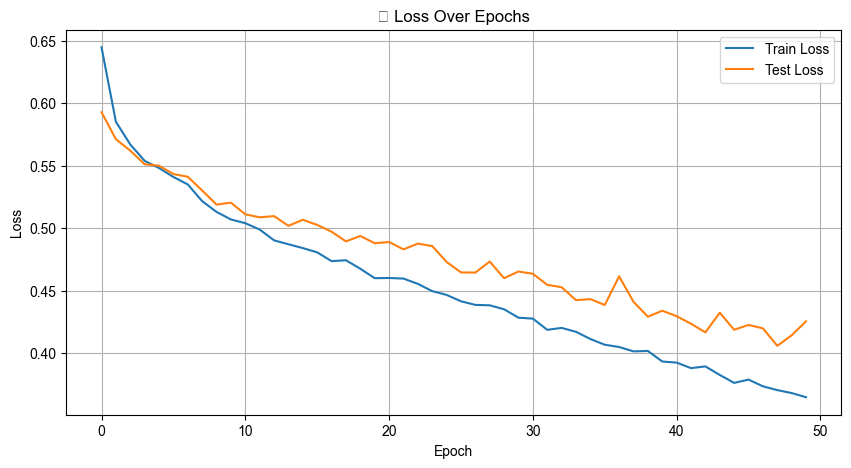

In [213]:
# Initialize variables for early stopping
best_loss = float("inf")
patience = 5
counter = 0
best_model_state = None  # Variable to store the best model state

train_losses = []
test_losses = []

# ------------------------------
# Training Loop
# ------------------------------
for epoch in range(50):
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb)
        loss = loss_fn(preds, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)

    # Evaluation
    model.eval()
    with torch.no_grad():
        xb, yb = X_test.to(device), y_test.to(device)
        val_preds = model(xb)
        val_loss = loss_fn(val_preds, yb).item()
        test_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:02} | Train Loss: {train_loss:.4f} | Test Loss: {val_loss:.4f}")

    # Early stopping logic
    if val_loss < best_loss:
        best_loss = val_loss
        best_model_state = model.state_dict()  # Save the best model state
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping.")
            break

# Load the best model state
model.load_state_dict(best_model_state)

# ----------------------------
# Plot Loss Curve
# ----------------------------
plt.rcParams['font.family'] = 'Arial'  # Set font family before plotting
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("📉 Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()